In [3]:
from qiskit.circuit import QuantumCircuit
from qiskit_aer import AerSimulator
import numpy as np
import matplotlib.pyplot as plt

In [16]:
qc = QuantumCircuit(3)
qc.h(2)
qc.cp(np.pi/2,1,2)
qc.cp(np.pi/4,0,2)
qc.draw()

q_0: ───────────────■───────
                    │       
q_1: ──────■────────┼───────
     ┌───┐ │P(π/2)  │P(π/4) 
q_2: ┤ H ├─■────────■───────
     └───┘

In [17]:
qc.h(1)
qc.cp(np.pi/2,0,1)
qc.h(0)
qc.swap(0,2)
qc.draw()

┌───┐   
q_0: ───────────────■─────────────■───────┤ H ├─X─
                    │       ┌───┐ │P(π/2) └───┘ │ 
q_1: ──────■────────┼───────┤ H ├─■─────────────┼─
     ┌───┐ │P(π/2)  │P(π/4) └───┘               │ 
q_2: ┤ H ├─■────────■───────────────────────────X─
     └───┘

General Function

In [17]:
def qft(n):
    qc1 = QuantumCircuit(n)
    for i in range(n-1,-1,-1):
        qc1.h(i)
        for j in range(i): 
            qc1.cp(np.pi/2**(i-j),j,i)

    for i in range(n//2):
        qc1.swap(i,n-i-1)
    qc1_gate = qc1.to_gate(label="QFT")
    return qc1_gate

def inverse_qft(n):
    qc1 = QuantumCircuit(n) 
    for i in range(n//2):
        qc1.swap(i,n-i-1)

    for i in range(n):
        for j in range(i):  
            qc1.cp(-np.pi/2**(i-j),j,i)
        qc1.h(i) 
        # qc1.barrier()
    inverse_qft_gate = qc1.to_gate(label="IQFT")
    # return qc1
    return inverse_qft_gate

qft_gate = qft(4)
iqft_gate = inverse_qft(c)

qc = QuantumCircuit(5) 
qc.append(qft_gate,range(4))
qc.append(iqft_gate,range(c))
qc.draw()
 

┌──────┐┌───────┐
q_0: ┤0     ├┤0      ├
     │      ││       │
q_1: ┤1     ├┤1      ├
     │  QFT ││       │
q_2: ┤2     ├┤2 IQFT ├
     │      ││       │
q_3: ┤3     ├┤3      ├
     └──────┘│       │
q_4: ────────┤4      ├
             └───────┘

<h4>Quantum Phase Estimation</h4>

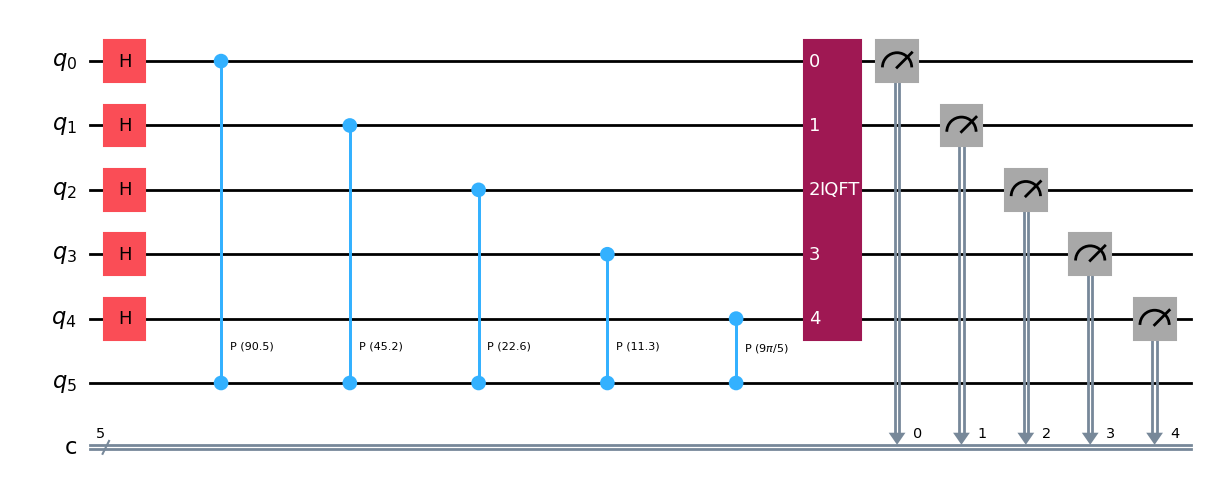

In [20]:
from qiskit.circuit import QuantumCircuit
import numpy as np
n,c = 1,5
qc = QuantumCircuit(n+c,c)
qc.h(range(c))
theta = 0.9
for i in range(c):
    exponent = 2**(c-i-1) 
    qc.cp(2*np.pi*theta*exponent,i,c+n-1) 
qc.append(iqft_gate,range(c)) 
for i in range(c):
    qc.measure(i,i)
qc.draw('mpl')

In [13]:
from qiskit_aer import AerSimulator
from qiskit import transpile
aer = AerSimulator()
qc_isa = transpile(qc,backend=aer)
job = aer.run(qc_isa,shots=1000)
result = job.result().get_counts()

In [14]:
result

{'00': 1000}